In [9]:
import pandas as pd

## Building Baseline Classifier

Baseline Model

The first baseline classifier uses a combination of semantic, categorical, and structural features to predict the manually annotated bug category. Features are intentionally limited to establish a reference performance before introducing more sophisticated repository-aware features in subsequent models.

for the first classifier we are going to use the following features and we will slowly add more to check if they contribute to better performance

Model 1 (Structural + Metadata Only)

semantic/categorical features
* project - (one hot encoding)
* exception types - (Multi-label One-Hot Encoding)

numeric features
* lines_added
* lines_removed
* num_of_hunks
* num_files_changed
* patch_length

Target: bug_category

A Bug could only belong to one bug_category under our dataset assumption so this is a **Multi Class Claissification Problem**

There is class imbalance in the dataset:
Type Handling: 103 ,Program Logic: 93 ...Date & Time: 14 
So, if we perform a random split, we could end up with very few (or even no) examples of Date & Time in the test set, making evaluation unreliable.

Solution: **Stratefication**
Using a stratified train-test split preserves the class proportions in both the training and test sets, giving us a more representative evaluation

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [11]:
ml_df=pd.read_csv("../data/processed/bug_dataset_ml.csv")
ml_df.head()

,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules,bug_category,label_reason,confidence
0,keras,32,3.7.3,a3d160b9467c99cbb27f9aa0382c759f45c8ee66,709f791af201caaab4aa180bda259989087cfe47,tests/keras/test_callbacks.py,diff --git a/keras/callbacks.py b/keras/callba...,NaN,['keras/callbacks.py'],1,...,"['__init__', 'in_cooldown']",5,2,['ValueError'],1,['keras'],1,API and Configuration,The patch renames a constructor keyword argume...,Medium
1,keras,35,3.7.3,06eaeebecfb73c23bfd531013ca172ee3bf5069c,738819de0b7e6bc45abed8d0640f02b81c6ac4e9,tests/keras/preprocessing/image_test.py,diff --git a/keras/preprocessing/image.py b/ke...,NaN,['keras/preprocessing/image.py'],1,...,[],3,0,['ValueError'],1,['keras/preprocessing'],1,API and Configuration,The patch relocates the user-supplied preproce...,Medium
2,keras,34,3.7.3,7ef5244a2f1f7f7b76e3c804b82cbb20cdf4d139,4b74fc5418944c9f449eb88ed4b40ada280fa5ca,tests/test_multiprocessing.py,diff --git a/keras/engine/training.py b/keras/...,NaN,"['keras/engine/training.py', 'keras/utils/data...",2,...,['__iter__'],5,1,[],0,"['keras/engine', 'keras/utils']",2,Collections and Indexing,The patch adds an __iter__ implementation and ...,Medium
3,keras,33,3.7.3,1c9a49781da2101507db23e2014e4e5d16bd2e52,70ad0d6e4a569701ef106058397ad0540ec08340,tests/keras/preprocessing/text_test.py,diff --git a/keras/preprocessing/text.py b/ker...,NaN,['keras/preprocessing/text.py'],1,...,['text_to_word_sequence'],0,1,[],0,['keras/preprocessing'],1,Type Handling,The patch corrects str/unicode assumptions and...,Medium
4,keras,20,3.7.3,76da5f0a21ca98e4bf6706e182fb825243e76204,6dd087ab73b09e449144ff17450cc14f981b9ac2,tests/keras/layers/convolutional_test.py,diff --git a/keras/backend/cntk_backend.py b/k...,NaN,"['keras/backend/cntk_backend.py', 'keras/backe...",5,...,"['in_top_k', 'conv2d_transpose', 'conv2d_trans...",5,22,['ValueError'],1,"['keras/backend', 'keras/layers', 'keras/utils']",3,API and Configuration,The patch threads a missing dilation_rate para...,Medium


In [8]:
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   project                                484 non-null    str  
 1   bug_id                                 484 non-null    int64
 2   python_version                         484 non-null    str  
 3   buggy_commit_id                        484 non-null    str  
 4   fixed_commit_id                        484 non-null    str  
 5   test_file                              484 non-null    str  
 6   patch                                  484 non-null    str  
 7   pythonpath                             28 non-null     str  
 8   modified_files                         484 non-null    str  
 9   num_files_changed                      484 non-null    int64
 10  lines_added                            484 non-null    int64
 11  lines_removed                          484 

In [9]:
ml_df.shape

(484, 26)

In [10]:
ml_df.columns.tolist()

['project',
 'bug_id',
 'python_version',
 'buggy_commit_id',
 'fixed_commit_id',
 'test_file',
 'patch',
 'pythonpath',
 'modified_files',
 'num_files_changed',
 'lines_added',
 'lines_removed',
 'num_hunks',
 'patch_length',
 'has_comment',
 'declared_classes_in_patch',
 'declared_functions_in_patch',
 'number_of_declared_classes_in_patch',
 'number_of_declared_functions_in_patch',
 'exception_types',
 'num_exception_types',
 'modified_modules',
 'num_modified_modules',
 'bug_category',
 'label_reason',
 'confidence']

In [11]:
ml_df["bug_category"].value_counts()

bug_category
Type Handling                         100
Program Logic and State Management     91
API and Configuration                  86
File, I/O and Data Processing          72
Input Validation                       49
Collections and Indexing               42
Numerical and Computational Logic      30
Date and Time                          14
Name: count, dtype: int64

In [12]:
#Target
y=ml_df["bug_category"]
y

0              API and Configuration
1              API and Configuration
2           Collections and Indexing
3                      Type Handling
4              API and Configuration
                   ...              
479         Collections and Indexing
480                    Type Handling
481            API and Configuration
482    File, I/O and Data Processing
483                    Date and Time
Name: bug_category, Length: 484, dtype: str

In [13]:
#Features
baseline_features = [
    "project",
    "exception_types",
    "lines_added",
    "lines_removed",
    "num_hunks",
    "num_files_changed",
    "patch_length"
]
X = ml_df[baseline_features].copy()
X.head()

,project,exception_types,lines_added,lines_removed,num_hunks,num_files_changed,patch_length
0,keras,['ValueError'],11,6,10,1,66
1,keras,['ValueError'],16,3,6,1,45
2,keras,[],22,4,10,2,69
3,keras,[],13,4,2,1,30
4,keras,['ValueError'],48,19,38,5,236


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [15]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (387, 7)
X_test: (97, 7)
y_train: (387,)
y_test: (97,)


In [16]:
print("Full dataset:")
print(y.value_counts(normalize=True).sort_index())

print("\nTrain:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest:")
print(y_test.value_counts(normalize=True).sort_index())

Full dataset:
bug_category
API and Configuration                 0.177686
Collections and Indexing              0.086777
Date and Time                         0.028926
File, I/O and Data Processing         0.148760
Input Validation                      0.101240
Numerical and Computational Logic     0.061983
Program Logic and State Management    0.188017
Type Handling                         0.206612
Name: proportion, dtype: float64

Train:
bug_category
API and Configuration                 0.178295
Collections and Indexing              0.087855
Date and Time                         0.028424
File, I/O and Data Processing         0.147287
Input Validation                      0.100775
Numerical and Computational Logic     0.062016
Program Logic and State Management    0.188630
Type Handling                         0.206718
Name: proportion, dtype: float64

Test:
bug_category
API and Configuration                 0.175258
Collections and Indexing              0.082474
Date and Time       

In [17]:
#compare proportions, not counts with value counts using normalize = True
comparison = pd.DataFrame({
    "Full": y.value_counts(normalize=True).sort_index(),
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index()
})

comparison

,Full,Train,Test
bug_category,,,
API and Configuration,0.177686,0.178295,0.175258
Collections and Indexing,0.086777,0.087855,0.082474
Date and Time,0.028926,0.028424,0.030928
"File, I/O and Data Processing",0.148760,0.147287,0.154639
Input Validation,0.101240,0.100775,0.103093
Numerical and Computational Logic,0.061983,0.062016,0.061856
Program Logic and State Management,0.188017,0.188630,0.185567
Type Handling,0.206612,0.206718,0.206186


## Transform features into numbers

Convert exception_types back to lists, loadinf from the CSV, converts it to a string

In [18]:
type(X_train["exception_types"].iloc[0])

str

In [19]:
#ast.literal_eval() safely converts the string representation of a Python literal, such as a list or dictionary, back into the corresponding Python object.
import ast 

X_train["exception_types"] = X_train["exception_types"].apply(ast.literal_eval)
X_test["exception_types"] = X_test["exception_types"].apply(ast.literal_eval)

In [20]:
X_train["exception_types"].head()

239              []
20               []
95               []
162    [ValueError]
315              []
Name: exception_types, dtype: object

In [21]:
type(X_train["exception_types"].iloc[0])

list

In [22]:
mlb = MultiLabelBinarizer()#one bug can belong to multiple exception types

train_exceptions = pd.DataFrame(mlb.fit_transform(X_train["exception_types"]),
                                columns=mlb.classes_,
                                index=X_train.index)
train_exceptions

,AbstractMethodError,AnsibleError,AssertionError,AttributeError,AuthError,ContextDecodingException,CookiecutterException,DateParseError,ExtractorError,FailedHookException,...,SyntaxError,TokenError,TqdmKeyError,TypeError,URLError,UnicodeEncodeError,UnicodeError,UnknownParameterException,UnknownTimeZoneError,ValueError
239,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
162,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
315,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
171,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
391,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
454,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
train_exceptions.info()

<class 'pandas.DataFrame'>
Index: 387 entries, 239 to 79
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   AbstractMethodError            387 non-null    int64
 1   AnsibleError                   387 non-null    int64
 2   AssertionError                 387 non-null    int64
 3   AttributeError                 387 non-null    int64
 4   AuthError                      387 non-null    int64
 5   ContextDecodingException       387 non-null    int64
 6   CookiecutterException          387 non-null    int64
 7   DateParseError                 387 non-null    int64
 8   ExtractorError                 387 non-null    int64
 9   FailedHookException            387 non-null    int64
 10  FormatError                    387 non-null    int64
 11  HTTPError                      387 non-null    int64
 12  HTTPException                  387 non-null    int64
 13  HadoopJarJobError              387 

In [24]:
train_exceptions.sum().sort_values(ascending=False)

ValueError                       50
TypeError                        27
KeyError                         11
NotImplementedError               9
ImportError                       5
AttributeError                    4
InvalidIndexError                 4
HTTPException                     3
RuntimeError                      3
MergeError                        3
IndexError                        3
AbstractMethodError               3
ExtractorError                    3
LookupError                       2
DateParseError                    2
URLError                          2
OSError                           2
OverflowError                     2
RequestValidationError            1
UnknownTimeZoneError              1
UnknownParameterException         1
UnicodeError                      1
UnicodeEncodeError                1
AssertionError                    1
TqdmKeyError                      1
TokenError                        1
SyntaxError                       1
AuthError                   

In [25]:
train_exceptions[train_exceptions["ValueError"] == 1].head()

,AbstractMethodError,AnsibleError,AssertionError,AttributeError,AuthError,ContextDecodingException,CookiecutterException,DateParseError,ExtractorError,FailedHookException,...,SyntaxError,TokenError,TqdmKeyError,TypeError,URLError,UnicodeEncodeError,UnicodeError,UnknownParameterException,UnknownTimeZoneError,ValueError
162,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
121,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
279,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [26]:
test_exceptions = pd.DataFrame(
    mlb.transform(X_test["exception_types"]),
    columns=mlb.classes_,
    index=X_test.index
)
train_exceptions[train_exceptions["TypeError"] == 1].head()

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['CalledProcessError', 'ValidationError'] will be ignored
  warnings.warn(


,AbstractMethodError,AnsibleError,AssertionError,AttributeError,AuthError,ContextDecodingException,CookiecutterException,DateParseError,ExtractorError,FailedHookException,...,SyntaxError,TokenError,TqdmKeyError,TypeError,URLError,UnicodeEncodeError,UnicodeError,UnknownParameterException,UnknownTimeZoneError,ValueError
395,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
325,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
451,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
433,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
466,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


Encode the project feature using **One Hot encoding**

In [27]:
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)


Why these parameters?

* handle_unknown="ignore"
    * If the test set contains a project that wasn’t seen during training, the encoder won’t crash. Instead, it outputs all zeros for that unseen category.
* sparse_output=False
    * Returns a regular NumPy array instead of a sparse matrix, making it easier to convert to a DataFrame and inspect.

In [28]:
train_projects = pd.DataFrame(
    encoder.fit_transform(X_train[["project"]]),#[[]] because OneHotEncoder expects a df
    columns=encoder.get_feature_names_out(["project"]),
    index=X_train.index
)
train_projects.head()

,project_PySnooper,project_ansible,project_black,project_cookiecutter,project_fastapi,project_httpie,project_keras,project_luigi,project_matplotlib,project_pandas,project_sanic,project_scrapy,project_spacy,project_thefuck,project_tornado,project_tqdm,project_youtube-dl
239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
162,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
315,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
test_projects = pd.DataFrame(
    encoder.transform(X_test[["project"]]),
    columns=encoder.get_feature_names_out(["project"]),
    index=X_test.index
)
test_projects.head()

,project_PySnooper,project_ansible,project_black,project_cookiecutter,project_fastapi,project_httpie,project_keras,project_luigi,project_matplotlib,project_pandas,project_sanic,project_scrapy,project_spacy,project_thefuck,project_tornado,project_tqdm,project_youtube-dl
247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
443,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


fit only on training data and transform the test data

combine the encoded categorical features with numeric features into the final training matrix

In [30]:
numeric_cols = [
    "lines_added",
    "lines_removed",
    "num_hunks",
    "num_files_changed",
    "patch_length"
]

train_numeric = X_train[numeric_cols]
test_numeric = X_test[numeric_cols]

In [31]:
X_train_final = pd.concat(
    [
        train_numeric,
        train_projects,
        train_exceptions
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        test_numeric,
        test_projects,
        test_exceptions
    ],
    axis=1
)

In [32]:
print(X_train_final.shape)
print(X_test_final.shape)

X_train_final.head()

(387, 63)
(97, 63)


,lines_added,lines_removed,num_hunks,num_files_changed,patch_length,project_PySnooper,project_ansible,project_black,project_cookiecutter,project_fastapi,...,SyntaxError,TokenError,TqdmKeyError,TypeError,URLError,UnicodeEncodeError,UnicodeError,UnknownParameterException,UnknownTimeZoneError,ValueError
239,3,0,2,1,14,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
20,14,1,8,1,52,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
95,7,2,8,2,45,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
162,8,8,4,1,42,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
315,40,9,2,1,63,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
# At this point all the features are numeric
X_train_final.dtypes.value_counts()

int64      46
float64    17
Name: count, dtype: int64

## 1. Logistic Regression

In [34]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

* max_iter=1000
    * Logistic Regression uses an optimization algorithm. The default (100) sometimes isn’t enough to converge, especially with many features.
    * 1000 avoids convergence warnings.
* class_weight=“balanced”
    * Automatically gives more weight to minority classes (like Date and Time) during training.
* random_state=42
    * Makes the results reproducible.

In [35]:
#Train
lr.fit(X_train_final, y_train)

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

Scikit-learn’s Logistic Regression with solver="lbfgs" uses the L-BFGS optimizer, which is a more advanced quasi-Newton optimization algorithm. It still minimizes the same loss function using gradient information, but it converges much faster than vanilla gradient descent . 
These optimizers converge much faster when numeric features have similar scales.
So we scale numeric fields using the standard scaler.

StandardScaler standardizes continuous input features to have zero mean and unit variance. This prevents features with larger numeric ranges, such as patch_length, from dominating the optimization process and helps gradient-based algorithms like Logistic Regression converge faster and more reliably

In [36]:
numeric_cols = [
    "lines_added",
    "lines_removed",
    "num_hunks",
    "num_files_changed",
    "patch_length"
]

Create the scaler + Fit and transform the training data

In [37]:
scaler = StandardScaler()
train_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)
train_numeric_scaled.head()

,lines_added,lines_removed,num_hunks,num_files_changed,patch_length
239,-0.368900,-0.398553,-0.367979,-0.363296,-0.448471
20,0.155093,-0.314590,0.400409,-0.363296,0.211380
95,-0.178357,-0.230627,0.400409,0.892021,0.089829
162,-0.130721,0.273151,-0.111850,-0.363296,0.037735
315,1.393621,0.357114,-0.367979,-0.363296,0.402390


Transform the test data

In [38]:
test_numeric_scaled = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)
test_numeric_scaled.head()

,lines_added,lines_removed,num_hunks,num_files_changed,patch_length
247,0.202729,0.441077,0.144279,-0.363296,0.332932
442,2.679785,1.868450,2.193312,0.892021,2.625046
443,1.107807,0.273151,0.400409,2.147337,0.680222
446,0.774357,1.700524,3.217829,-0.363296,2.208298
424,-0.464171,-0.314590,-0.367979,-0.363296,-0.465835


In [39]:
train_numeric_scaled.describe().round(2)

,lines_added,lines_removed,num_hunks,num_files_changed,patch_length
count,387.00,387.00,387.00,387.00,387.00
mean,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.51,-0.40,-0.37,-0.36,-0.52
25%,-0.42,-0.31,-0.37,-0.36,-0.43
50%,-0.27,-0.23,-0.37,-0.36,-0.29
75%,0.01,-0.06,-0.11,-0.36,0.02
max,9.35,14.55,14.74,8.42,11.20


The standard deviation is 1 after scaling

Rebuild the final matrices

In [40]:
X_train_final = pd.concat(
    [
        train_numeric_scaled,
        train_projects,
        train_exceptions
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        test_numeric_scaled,
        test_projects,
        test_exceptions
    ],
    axis=1
)

In [41]:
lr_scaled = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_scaled.fit(X_train_final, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

Predict on the test set

In [42]:
y_pred = lr_scaled.predict(X_test_final)

Evaluate

In [43]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

print(f"Macro Precision: {precision_score(y_test, y_pred, average='macro'):.3f}")

print(f"Macro Recall: {recall_score(y_test, y_pred, average='macro'):.3f}")

print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")

Accuracy: 0.299
Macro Precision: 0.318
Macro Recall: 0.296
Macro F1: 0.274


Because  classes are imbalanced.Macro metrics compute the metric for each class independently and then average them, so every bug category contributes equally—even the smaller Date and Time class.

Detailed per-class report

In [44]:
print(classification_report(y_test, y_pred))

                                    precision    recall  f1-score   support

             API and Configuration       0.50      0.35      0.41        17
          Collections and Indexing       0.12      0.12      0.12         8
                     Date and Time       0.05      0.33      0.08         3
     File, I/O and Data Processing       0.23      0.20      0.21        15
                  Input Validation       0.33      0.60      0.43        10
 Numerical and Computational Logic       0.20      0.17      0.18         6
Program Logic and State Management       0.54      0.39      0.45        18
                     Type Handling       0.57      0.20      0.30        20

                          accuracy                           0.30        97
                         macro avg       0.32      0.30      0.27        97
                      weighted avg       0.40      0.30      0.32        97



Confusion matrix

In [45]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6 3 2 1 1 3 1 0]
 [3 1 2 1 1 0 0 0]
 [0 0 1 1 1 0 0 0]
 [0 1 3 3 6 0 1 1]
 [0 1 2 0 6 0 1 0]
 [0 0 1 0 0 1 2 2]
 [2 1 4 1 2 1 7 0]
 [1 1 6 6 1 0 1 4]]


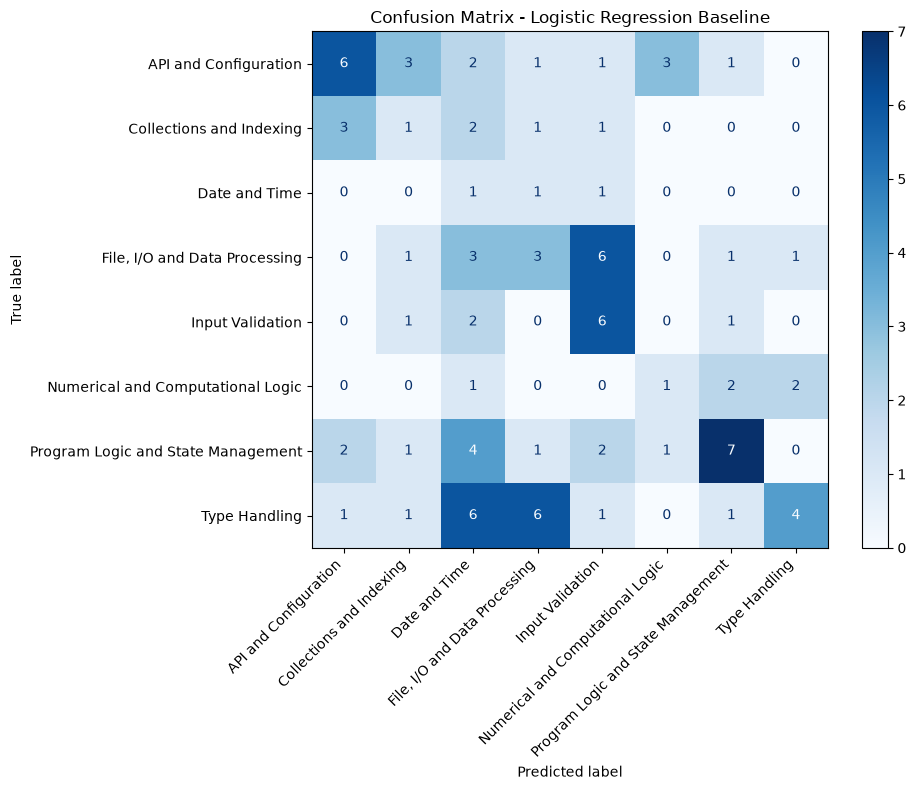

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax

)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.xticks(ha="right")
plt.tight_layout()

plt.show()

## Baseline Logistic Regression

Features
---------
* project
* exception_types
* lines_added
* lines_removed
* num_hunks
* num_files_changed
* patch_length

Metrics
--------

* Accuracy:        0.299
* Macro Precision: 0.318
* Macro Recall:    0.296
* Macro F1:        0.274

## 2. Linear SVM

Exactly the same features.
If Linear SVM performs better, then the improvement comes from the classifier, not the features.

For sparse, high-dimensional data , Linear SVM is one of the strongest classical baselines.

In [47]:
svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train_final, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`inte

Predict on the test set

In [48]:
y_pred = svm.predict(X_test_final)

Evaluate

In [49]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

print(f"Macro Precision: {precision_score(y_test, y_pred, average='macro'):.3f}")

print(f"Macro Recall: {recall_score(y_test, y_pred, average='macro'):.3f}")

print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")

Accuracy: 0.309
Macro Precision: 0.299
Macro Recall: 0.260
Macro F1: 0.265


In [50]:
print(classification_report(y_test, y_pred))

                                    precision    recall  f1-score   support

             API and Configuration       0.43      0.35      0.39        17
          Collections and Indexing       0.33      0.12      0.18         8
                     Date and Time       0.00      0.00      0.00         3
     File, I/O and Data Processing       0.21      0.20      0.21        15
                  Input Validation       0.28      0.50      0.36        10
 Numerical and Computational Logic       0.17      0.17      0.17         6
Program Logic and State Management       0.64      0.39      0.48        18
                     Type Handling       0.33      0.35      0.34        20

                          accuracy                           0.31        97
                         macro avg       0.30      0.26      0.27        97
                      weighted avg       0.36      0.31      0.32        97



SVM never predicted Date and Time correctly.

In [51]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6 1 0 1 2 3 1 3]
 [3 1 1 1 1 0 0 1]
 [0 0 0 1 1 0 0 1]
 [2 0 3 3 5 0 0 2]
 [1 0 2 0 5 0 1 1]
 [0 0 0 0 0 1 2 3]
 [1 1 1 2 2 1 7 3]
 [1 0 3 6 2 1 0 7]]


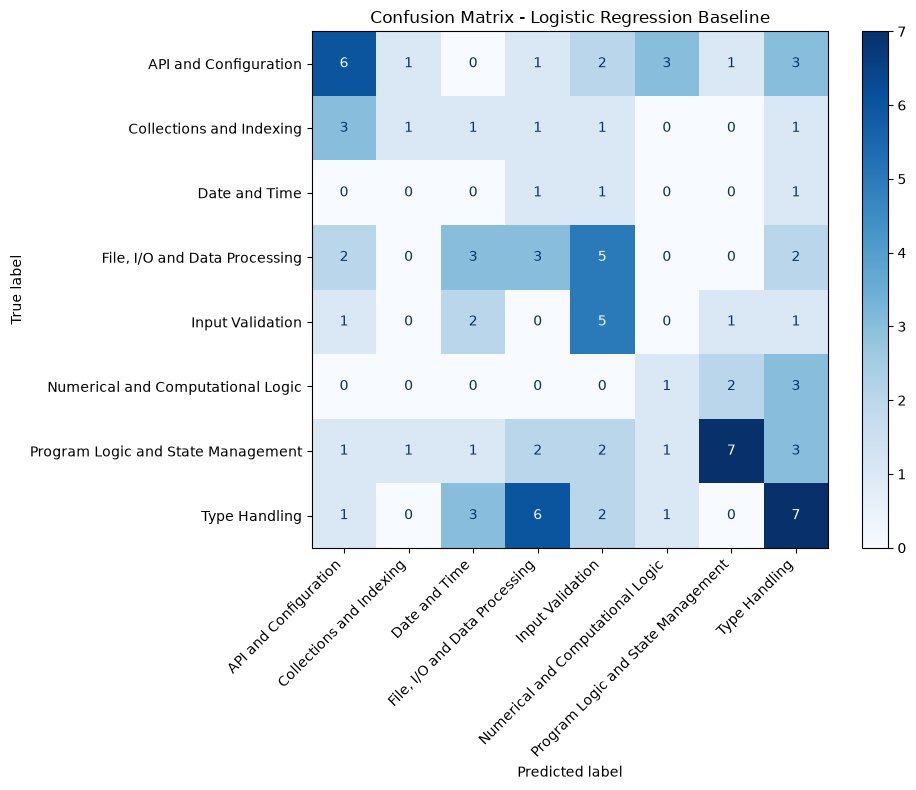

In [52]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax

)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.xticks(ha="right")
plt.tight_layout()

plt.show()

Although Linear SVM has slightly higher accuracy (30.9% vs. 29.9%), it has a lower Macro F1 score.
* Accuracy is influenced by the larger classes.
* Macro F1 gives every class equal importance.

If a model predicts only the four largest classes.
It might get a decent accuracy because most samples belong to those classes.
But it’s useless if it completely ignores the minority classes.

dataset is imbalanced, Macro F1 is the better metric.

### Linear SVM achieved a marginally higher overall accuracy than Logistic Regression but exhibited lower macro-averaged precision, recall, and F1-score. In particular, it failed to correctly identify any instances of the minority “Date and Time” class, indicating poorer performance on underrepresented categories. Consequently, Logistic Regression was selected as the stronger baseline model for subsequent feature engineering experiments.

In [53]:
train_patch = ml_df.loc[X_train.index, "patch"].fillna("")
test_patch = ml_df.loc[X_test.index, "patch"].fillna("")

In [54]:
train_patch.head()

239    diff --git a/lib/matplotlib/axes/_axes.py b/li...
20     diff --git a/keras/callbacks.py b/keras/callba...
95     diff --git a/luigi/interface.py b/luigi/interf...
162    diff --git a/lib/ansible/utils/version.py b/li...
315    diff --git a/black.py b/black.py\nindex 2df03f...
Name: patch, dtype: str

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

train_patch_tfidf = tfidf.fit_transform(train_patch)

test_patch_tfidf = tfidf.transform(test_patch)

In [56]:
print("Train:", train_patch_tfidf.shape)
print("Test:", test_patch_tfidf.shape)

print("Vocabulary size:", len(tfidf.get_feature_names_out()))

Train: (387, 5000)
Test: (97, 5000)
Vocabulary size: 5000


In [57]:
feature_names = tfidf.get_feature_names_out()

row = train_patch_tfidf[0]

nonzero_indices = row.nonzero()[1]

for i in nonzero_indices:
    print(feature_names[i], ":", row[0, i])

diff : 0.019106011798525415
git : 0.019106011798525415
lib : 0.2315021728794602
matplotlib : 0.28299127700906973
axes : 0.3154625702766519
_axes : 0.3640674057993794
py : 0.07642404719410166
index : 0.019106011798525415
636868f87 : 0.11975377193854775
100644 : 0.01955441335996402
6573 : 0.2395075438770955
optional : 0.0777735732399519
if : 0.06999749714175503
bin_range : 0.3592613158156432
is : 0.0708855913629375
not : 0.09416696040023753
none : 0.07042519996725218
self : 0.06094929818965759
convert_xunits : 0.2395075438770955
cbook : 0.1820337028996897
bins : 0.29629101776774946
we : 0.056088633252040686
need : 0.08002393730886892
to : 0.12316619723404754
do : 0.0871828347747267
weights : 0.3950546903569993
what : 0.10224711040448065
was : 0.08900383219458771
done : 0.0871828347747267


In [58]:
row = train_patch_tfidf[0]

print("Sum:", row.sum())
print("Sum of squares:", row.power(2).sum())

Sum: 4.2478230086922935
Sum of squares: 1.0000000000000002


In [59]:
from scipy.sparse import hstack, csr_matrix
X_train_combined = hstack([
    csr_matrix(X_train_final.values),
    train_patch_tfidf
]).tocsr()

X_test_combined = hstack([
    csr_matrix(X_test_final.values),
    test_patch_tfidf
]).tocsr()

In [60]:
print(X_train_combined.shape)
print(X_test_combined.shape)
print(type(X_train_combined))

(387, 5063)
(97, 5063)
<class 'scipy.sparse._csr.csr_matrix'>


In [61]:
lr_tfidf = LogisticRegression(

    max_iter=2000,

    class_weight="balanced",

    random_state=42

)

lr_tfidf.fit(X_train_combined, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [62]:
y_pred_tfidf = lr_tfidf.predict(X_test_combined)

In [63]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf):.3f}")

print(f"Macro Precision: {precision_score(y_test, y_pred_tfidf, average='macro'):.3f}")

print(f"Macro Recall: {recall_score(y_test, y_pred_tfidf, average='macro'):.3f}")

print(f"Macro F1: {f1_score(y_test, y_pred_tfidf, average='macro'):.3f}")

print(classification_report(y_test, y_pred_tfidf))

Accuracy: 0.474
Macro Precision: 0.472
Macro Recall: 0.461
Macro F1: 0.460
                                    precision    recall  f1-score   support

             API and Configuration       0.53      0.47      0.50        17
          Collections and Indexing       0.33      0.38      0.35         8
                     Date and Time       0.50      0.33      0.40         3
     File, I/O and Data Processing       0.41      0.47      0.44        15
                  Input Validation       0.38      0.60      0.46        10
 Numerical and Computational Logic       0.50      0.50      0.50         6
Program Logic and State Management       0.53      0.44      0.48        18
                     Type Handling       0.59      0.50      0.54        20

                          accuracy                           0.47        97
                         macro avg       0.47      0.46      0.46        97
                      weighted avg       0.49      0.47      0.48        97



In [64]:
svm_tfidf = LinearSVC(

    class_weight="balanced",

    random_state=42

)

svm_tfidf.fit(X_train_combined, y_train)

y_pred_svm_tfidf = svm_tfidf.predict(X_test_combined)

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [65]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_tfidf):.3f}")
print(f"Macro Precision: {precision_score(y_test, y_pred_svm_tfidf, average='macro'):.3f}")
print(f"Macro Recall: {recall_score(y_test, y_pred_svm_tfidf, average='macro'):.3f}")
print(f"Macro F1: {f1_score(y_test, y_pred_svm_tfidf, average='macro'):.3f}")

print(classification_report(y_test, y_pred_svm_tfidf))

Accuracy: 0.546
Macro Precision: 0.588
Macro Recall: 0.505
Macro F1: 0.525
                                    precision    recall  f1-score   support

             API and Configuration       0.52      0.76      0.62        17
          Collections and Indexing       0.50      0.25      0.33         8
                     Date and Time       0.50      0.33      0.40         3
     File, I/O and Data Processing       0.44      0.53      0.48        15
                  Input Validation       0.60      0.60      0.60        10
 Numerical and Computational Logic       1.00      0.50      0.67         6
Program Logic and State Management       0.58      0.61      0.59        18
                     Type Handling       0.56      0.45      0.50        20

                          accuracy                           0.55        97
                         macro avg       0.59      0.51      0.52        97
                      weighted avg       0.56      0.55      0.54        97



In [66]:
train_modules = ml_df.loc[X_train.index, "modified_modules"].fillna("[]")
test_modules = ml_df.loc[X_test.index, "modified_modules"].fillna("[]")

print(train_modules.iloc[0])
print(type(train_modules.iloc[0]))

['lib/matplotlib/axes']
<class 'str'>


In [67]:
train_modules = train_modules.apply(ast.literal_eval)

test_modules = test_modules.apply(ast.literal_eval)

In [68]:
print(train_modules.iloc[0])
print(type(train_modules.iloc[0]))

['lib/matplotlib/axes']
<class 'list'>


In [69]:
module_mlb = MultiLabelBinarizer()

train_modules_encoded = module_mlb.fit_transform(train_modules)

test_modules_encoded = module_mlb.transform(test_modules)

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['blib2to3', 'examples/userdemo', 'lib/ansible/plugins/shell', 'pandas/tests/arrays', 'pandas/tests/frame', 'scrapy/core/downloader/handlers', 'scrapy/http/response', 'spacy/cli/converters', 'tornado/platform', 'tutorials/colors', 'youtube_dl/postprocessor'] will be ignored
  warnings.warn(


In [70]:
print(train_modules_encoded.shape)
print(test_modules_encoded.shape)
print("Unique module features:", len(module_mlb.classes_))

(387, 102)
(97, 102)
Unique module features: 102


In [71]:
print(module_mlb.classes_[:20])

['.' 'bin/wiki_entity_linking' 'blib2to3/pgen2' 'cookiecutter' 'docs'
 'examples/information_extraction' 'fastapi' 'fastapi/dependencies'
 'fastapi/openapi' 'fastapi/security' 'httpie' 'keras'
 'keras/applications' 'keras/backend' 'keras/engine' 'keras/layers'
 'keras/preprocessing' 'keras/utils' 'keras/wrappers' 'lib/ansible/cli']


In [72]:
X_train_repo = hstack([

    X_train_combined,

    csr_matrix(train_modules_encoded)

]).tocsr()

X_test_repo = hstack([

    X_test_combined,

    csr_matrix(test_modules_encoded)

]).tocsr()

In [73]:
print(X_train_repo.shape)
print(X_test_repo.shape)

(387, 5165)
(97, 5165)


In [74]:
svm_repo = LinearSVC(

    class_weight="balanced",

    random_state=42

)

svm_repo.fit(X_train_repo, y_train)

y_pred_repo = svm_repo.predict(X_test_repo)

In [75]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_repo):.3f}")
print(f"Macro Precision: {precision_score(y_test, y_pred_repo, average='macro'):.3f}")
print(f"Macro Recall: {recall_score(y_test, y_pred_repo, average='macro'):.3f}")
print(f"Macro F1: {f1_score(y_test, y_pred_repo, average='macro'):.3f}")

print(classification_report(y_test, y_pred_repo))

Accuracy: 0.505
Macro Precision: 0.495
Macro Recall: 0.475
Macro F1: 0.473
                                    precision    recall  f1-score   support

             API and Configuration       0.50      0.65      0.56        17
          Collections and Indexing       0.29      0.25      0.27         8
                     Date and Time       0.50      0.33      0.40         3
     File, I/O and Data Processing       0.47      0.47      0.47        15
                  Input Validation       0.46      0.60      0.52        10
 Numerical and Computational Logic       0.43      0.50      0.46         6
Program Logic and State Management       0.50      0.56      0.53        18
                     Type Handling       0.82      0.45      0.58        20

                          accuracy                           0.51        97
                         macro avg       0.50      0.48      0.47        97
                      weighted avg       0.53      0.51      0.51        97



In [76]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [77]:
for fold, (train_idx, val_idx) in enumerate(
    skf.split(ml_df, ml_df["bug_category"]),
    start=1
):
    print(
        f"Fold {fold}: "
        f"Train = {len(train_idx)}, "
        f"Validation = {len(val_idx)}"
    )

Fold 1: Train = 387, Validation = 97
Fold 2: Train = 387, Validation = 97
Fold 3: Train = 387, Validation = 97
Fold 4: Train = 387, Validation = 97
Fold 5: Train = 388, Validation = 96


In [78]:
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(

    skf.split(ml_df, ml_df["bug_category"]),

    start=1

):

    # Get this fold's data

    fold_train = ml_df.iloc[train_idx]

    fold_val = ml_df.iloc[val_idx]

    # Patch text

    train_patch = fold_train["patch"].fillna("")

    val_patch = fold_val["patch"].fillna("")

    # Target

    y_fold_train = fold_train["bug_category"]

    y_fold_val = fold_val["bug_category"]

    # NEW TF-IDF vectorizer for this fold

    tfidf_fold = TfidfVectorizer(max_features=5000)

    X_fold_train = tfidf_fold.fit_transform(train_patch)

    X_fold_val = tfidf_fold.transform(val_patch)

    # NEW SVM for this fold

    svm_fold = LinearSVC(

        class_weight="balanced",

        random_state=42

    )

    svm_fold.fit(X_fold_train, y_fold_train)

    y_fold_pred = svm_fold.predict(X_fold_val)

    score = f1_score(

        y_fold_val,

        y_fold_pred,

        average="macro"

    )

    fold_scores.append(score)

    print(f"Fold {fold} Macro F1: {score:.3f}")

Fold 1 Macro F1: 0.397
Fold 2 Macro F1: 0.489
Fold 3 Macro F1: 0.451
Fold 4 Macro F1: 0.430
Fold 5 Macro F1: 0.432


In [79]:
print("Scores:", fold_scores)

print("Mean Macro F1:", np.mean(fold_scores))

print("Std:", np.std(fold_scores))

Scores: [0.397103393978394, 0.48899781141307325, 0.4512467440099019, 0.4302473872516712, 0.4315477127977128]
Mean Macro F1: 0.4398286098901506
Std: 0.030112460290677944


In [80]:
numeric_cols = [

    "lines_added",

    "lines_removed",

    "num_hunks",

    "num_files_changed",

    "patch_length"

]

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

fold_scores_full = []

for fold, (train_idx, val_idx) in enumerate(

    skf.split(ml_df, ml_df["bug_category"]),

    start=1

):

    fold_train = ml_df.iloc[train_idx].copy()

    fold_val = ml_df.iloc[val_idx].copy()

    y_fold_train = fold_train["bug_category"]

    y_fold_val = fold_val["bug_category"]

    # ---------------------------

    # 1. Numeric features

    # ---------------------------

    scaler = StandardScaler()

    train_numeric = scaler.fit_transform(

        fold_train[numeric_cols]

    )

    val_numeric = scaler.transform(

        fold_val[numeric_cols]

    )

    # ---------------------------

    # 2. Project

    # ---------------------------

    encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=True

    )

    train_project = encoder.fit_transform(

        fold_train[["project"]]

    )

    val_project = encoder.transform(

        fold_val[["project"]]

    )

    # ---------------------------

    # 3. Exception types

    # ---------------------------

    train_exceptions = fold_train["exception_types"].apply(ast.literal_eval)

    val_exceptions = fold_val["exception_types"].apply(ast.literal_eval)

    exception_mlb = MultiLabelBinarizer()

    train_exception_encoded = exception_mlb.fit_transform(

        train_exceptions

    )

    val_exception_encoded = exception_mlb.transform(

        val_exceptions

    )

    # ---------------------------

    # 4. Patch TF-IDF

    # ---------------------------

    tfidf = TfidfVectorizer(

        max_features=5000

    )

    train_patch_tfidf = tfidf.fit_transform(

        fold_train["patch"].fillna("")

    )

    val_patch_tfidf = tfidf.transform(

        fold_val["patch"].fillna("")

    )

    # ---------------------------

    # 5. Combine everything

    # ---------------------------

    X_fold_train = hstack([

        csr_matrix(train_numeric),

        train_project,

        csr_matrix(train_exception_encoded),

        train_patch_tfidf

    ]).tocsr()

    X_fold_val = hstack([

        csr_matrix(val_numeric),

        val_project,

        csr_matrix(val_exception_encoded),

        val_patch_tfidf

    ]).tocsr()

    # ---------------------------

    # 6. Train SVM

    # ---------------------------

    svm = LinearSVC(

        class_weight="balanced",

        random_state=42

    )

    svm.fit(X_fold_train, y_fold_train)

    y_fold_pred = svm.predict(X_fold_val)

    score = f1_score(

        y_fold_val,

        y_fold_pred,

        average="macro"

    )

    fold_scores_full.append(score)

    print(

        f"Fold {fold} | "

        f"Features: {X_fold_train.shape[1]} | "

        f"Macro F1: {score:.3f}"

    )

Fold 1 | Features: 5061 | Macro F1: 0.397


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['AuthError', 'CalledProcessError', 'RequestValidationError', 'TokenError'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['HadoopJarJobError', 'IndexingError', 'MissingParameterException'] will be ignored
  warnings.warn(


Fold 2 | Features: 5062 | Macro F1: 0.478


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['TqdmKeyError', 'UnicodeEncodeError', 'UnknownParameterException', 'ValidationError'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['FormatError', 'LookupError', 'SyntaxError'] will be ignored
  warnings.warn(


Fold 3 | Features: 5061 | Macro F1: 0.433
Fold 4 | Features: 5062 | Macro F1: 0.422
Fold 5 | Features: 5056 | Macro F1: 0.439


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['ContextDecodingException', 'CookiecutterException', 'DateParseError', 'FailedHookException', 'HTTPError', 'InvalidModeException', 'NonTemplatedInputDirException', 'OutputDirExistsException', 'UnknownTimeZoneError'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [81]:
print("\nScores:", fold_scores_full)
print("Mean Macro F1:", np.mean(fold_scores_full))
print("Std:", np.std(fold_scores_full))


Scores: [0.3969996705828844, 0.47828185328185324, 0.4327542125504774, 0.4219571321351507, 0.4392445662752422]
Mean Macro F1: 0.43384748696512154
Std: 0.026472169288203888


We’ve now learned three pretty important things:

Patch content is the dominant signal. TF-IDF alone gets ~0.44 Macro F1.

Basic structural metadata doesn’t meaningfully help.

Raw module-path repository features actually hurt on our original split, so naive repository awareness isn’t necessarily useful.

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [83]:
tree_train_scores = []

tree_val_scores = []

for fold, (train_idx, val_idx) in enumerate(

    skf.split(ml_df, ml_df["bug_category"]),

    start=1

):

    fold_train = ml_df.iloc[train_idx].copy()

    fold_val = ml_df.iloc[val_idx].copy()

    y_train_fold = fold_train["bug_category"]

    y_val_fold = fold_val["bug_category"]

    # -------------------------

    # 1. Numeric features

    # -------------------------

    X_train_numeric = csr_matrix(

        fold_train[numeric_cols].values

    )

    X_val_numeric = csr_matrix(

        fold_val[numeric_cols].values

    )

    # -------------------------

    # 2. Project

    # -------------------------

    project_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=True

    )

    X_train_project = project_encoder.fit_transform(

        fold_train[["project"]]

    )

    X_val_project = project_encoder.transform(

        fold_val[["project"]]

    )

    # -------------------------

    # 3. Exception types

    # -------------------------

    train_exceptions = fold_train["exception_types"].apply(ast.literal_eval)

    val_exceptions = fold_val["exception_types"].apply(ast.literal_eval)

    exception_mlb = MultiLabelBinarizer()

    X_train_exception = exception_mlb.fit_transform(

        train_exceptions

    )

    X_val_exception = exception_mlb.transform(

        val_exceptions

    )

    # -------------------------

    # 4. Combine features

    # -------------------------

    X_train_tree = hstack([

        X_train_numeric,

        X_train_project,

        csr_matrix(X_train_exception)

    ]).tocsr()

    X_val_tree = hstack([

        X_val_numeric,

        X_val_project,

        csr_matrix(X_val_exception)

    ]).tocsr()

    # -------------------------

    # 5. Decision Tree

    # -------------------------

    tree = DecisionTreeClassifier(

         max_depth=5,

        class_weight="balanced",

        random_state=42

    )

    tree.fit(X_train_tree, y_train_fold)

    # Predict BOTH training and validation

    train_pred = tree.predict(X_train_tree)

    val_pred = tree.predict(X_val_tree)

    train_f1 = f1_score(

        y_train_fold,

        train_pred,

        average="macro"

    )

    val_f1 = f1_score(

        y_val_fold,

        val_pred,

        average="macro"

    )

    tree_train_scores.append(train_f1)

    tree_val_scores.append(val_f1)

    print(

        f"Fold {fold}: "

        f"Train F1 = {train_f1:.3f} | "

        f"Validation F1 = {val_f1:.3f}"

    )

Fold 1: Train F1 = 0.328 | Validation F1 = 0.224
Fold 2: Train F1 = 0.337 | Validation F1 = 0.168
Fold 3: Train F1 = 0.379 | Validation F1 = 0.238
Fold 4: Train F1 = 0.351 | Validation F1 = 0.160
Fold 5: Train F1 = 0.364 | Validation F1 = 0.180


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['AuthError', 'CalledProcessError', 'RequestValidationError', 'TokenError'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['HadoopJarJobError', 'IndexingError', 'MissingParameterException'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['TqdmKeyError', 'UnicodeEncodeError', 'UnknownParameterException', 'ValidationError'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['FormatError', 'LookupErr

In [84]:
print("\nMean Train Macro F1:", np.mean(tree_train_scores))
print("Mean Validation Macro F1:", np.mean(tree_val_scores))
print("Validation Std:", np.std(tree_val_scores))


Mean Train Macro F1: 0.35185258473393743
Mean Validation Macro F1: 0.19409651547074827
Validation Std: 0.03119058034132262


In [85]:
depths = [3, 5, 8, 10, 15, 20, None]

depth_results = []

for depth in depths:
    train_scores = []
    val_scores = []

    for train_idx, val_idx in skf.split(
        ml_df,
        ml_df["bug_category"]
    ):
        fold_train = ml_df.iloc[train_idx].copy()
        fold_val = ml_df.iloc[val_idx].copy()

        y_train_fold = fold_train["bug_category"]
        y_val_fold = fold_val["bug_category"]

        # Numeric features
        X_train_numeric = csr_matrix(
            fold_train[numeric_cols].values
        )
        X_val_numeric = csr_matrix(
            fold_val[numeric_cols].values
        )

        # Project
        project_encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )

        X_train_project = project_encoder.fit_transform(
            fold_train[["project"]]
        )

        X_val_project = project_encoder.transform(
            fold_val[["project"]]
        )

        # Exception types
        train_exceptions = fold_train["exception_types"].apply(ast.literal_eval)
        val_exceptions = fold_val["exception_types"].apply(ast.literal_eval)

        exception_mlb = MultiLabelBinarizer()

        X_train_exception = exception_mlb.fit_transform(
            train_exceptions
        )

        X_val_exception = exception_mlb.transform(
            val_exceptions
        )

        # Combine
        X_train_tree = hstack([
            X_train_numeric,
            X_train_project,
            csr_matrix(X_train_exception)
        ]).tocsr()

        X_val_tree = hstack([
            X_val_numeric,
            X_val_project,
            csr_matrix(X_val_exception)
        ]).tocsr()

        # Decision Tree
        tree = DecisionTreeClassifier(
            max_depth=depth,
            class_weight="balanced",
            random_state=42
        )

        tree.fit(X_train_tree, y_train_fold)

        train_pred = tree.predict(X_train_tree)
        val_pred = tree.predict(X_val_tree)

        train_scores.append(
            f1_score(y_train_fold, train_pred, average="macro")
        )

        val_scores.append(
            f1_score(y_val_fold, val_pred, average="macro")
        )

    depth_results.append({
        "depth": depth,
        "train_f1": np.mean(train_scores),
        "val_f1": np.mean(val_scores),
        "val_std": np.std(val_scores)
    })

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['AuthError', 'CalledProcessError', 'RequestValidationError', 'TokenError'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['HadoopJarJobError', 'IndexingError', 'MissingParameterException'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['TqdmKeyError', 'UnicodeEncodeError', 'UnknownParameterException', 'ValidationError'] will be ignored
  warnings.warn(
/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['FormatError', 'LookupErr

In [86]:
for result in depth_results:
    print(
        f"Depth: {str(result['depth']):>4} | "
        f"Train F1: {result['train_f1']:.3f} | "
        f"Validation F1: {result['val_f1']:.3f} | "
        f"Std: {result['val_std']:.3f}"
    )

Depth:    3 | Train F1: 0.205 | Validation F1: 0.136 | Std: 0.018
Depth:    5 | Train F1: 0.352 | Validation F1: 0.194 | Std: 0.031
Depth:    8 | Train F1: 0.589 | Validation F1: 0.244 | Std: 0.040
Depth:   10 | Train F1: 0.690 | Validation F1: 0.238 | Std: 0.040
Depth:   15 | Train F1: 0.852 | Validation F1: 0.257 | Std: 0.048
Depth:   20 | Train F1: 0.897 | Validation F1: 0.254 | Std: 0.051
Depth: None | Train F1: 0.909 | Validation F1: 0.234 | Std: 0.039


The best validation performance is:
max_depth=15
Macro F1=0.257

A single decision tree shows substantial variance and overfitting. Random Forest builds many decorrelated decision trees and aggregates their predictions, which is specifically designed to reduce the variance of a single tree.

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_train_scores = []
rf_val_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(ml_df, ml_df["bug_category"]),
    start=1
):
    fold_train = ml_df.iloc[train_idx].copy()
    fold_val = ml_df.iloc[val_idx].copy()

    y_train_fold = fold_train["bug_category"]
    y_val_fold = fold_val["bug_category"]

    # Numeric
    X_train_numeric = csr_matrix(
        fold_train[numeric_cols].values
    )

    X_val_numeric = csr_matrix(
        fold_val[numeric_cols].values
    )

    # Project
    project_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )

    X_train_project = project_encoder.fit_transform(
        fold_train[["project"]]
    )

    X_val_project = project_encoder.transform(
        fold_val[["project"]]
    )

    # Exception types
    train_exceptions = fold_train["exception_types"].apply(ast.literal_eval)
    val_exceptions = fold_val["exception_types"].apply(ast.literal_eval)

    exception_mlb = MultiLabelBinarizer()

    X_train_exception = exception_mlb.fit_transform(
        train_exceptions
    )

    X_val_exception = exception_mlb.transform(
        val_exceptions
    )

    # Combine
    X_train_rf = hstack([
        X_train_numeric,
        X_train_project,
        csr_matrix(X_train_exception)
    ]).tocsr()

    X_val_rf = hstack([
        X_val_numeric,
        X_val_project,
        csr_matrix(X_val_exception)
    ]).tocsr()

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_rf, y_train_fold)

    train_pred = rf.predict(X_train_rf)
    val_pred = rf.predict(X_val_rf)

    train_f1 = f1_score(
        y_train_fold,
        train_pred,
        average="macro"
    )

    val_f1 = f1_score(
        y_val_fold,
        val_pred,
        average="macro"
    )

    rf_train_scores.append(train_f1)
    rf_val_scores.append(val_f1)

    print(
        f"Fold {fold}: "
        f"Train F1 = {train_f1:.3f} | "
        f"Validation F1 = {val_f1:.3f}"
    )

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['AuthError', 'CalledProcessError', 'RequestValidationError', 'TokenError'] will be ignored
  warnings.warn(


Fold 1: Train F1 = 0.906 | Validation F1 = 0.306


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['HadoopJarJobError', 'IndexingError', 'MissingParameterException'] will be ignored
  warnings.warn(


Fold 2: Train F1 = 0.924 | Validation F1 = 0.220


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['TqdmKeyError', 'UnicodeEncodeError', 'UnknownParameterException', 'ValidationError'] will be ignored
  warnings.warn(


Fold 3: Train F1 = 0.903 | Validation F1 = 0.256


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['FormatError', 'LookupError', 'SyntaxError'] will be ignored
  warnings.warn(


Fold 4: Train F1 = 0.910 | Validation F1 = 0.287


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['ContextDecodingException', 'CookiecutterException', 'DateParseError', 'FailedHookException', 'HTTPError', 'InvalidModeException', 'NonTemplatedInputDirException', 'OutputDirExistsException', 'UnknownTimeZoneError'] will be ignored
  warnings.warn(


Fold 5: Train F1 = 0.900 | Validation F1 = 0.249


In [88]:
print("\nMean Train Macro F1:", np.mean(rf_train_scores))
print("Mean Validation Macro F1:", np.mean(rf_val_scores))
print("Validation Std:", np.std(rf_val_scores))


Mean Train Macro F1: 0.9086753279296371
Mean Validation Macro F1: 0.2637536947851998
Validation Std: 0.029919099995779328


Going from a linear model to a more complex nonlinear ensemble didn’t compensate for weak features. Adding informative patch-text features produced a much larger improvement.

In [89]:
rf_tfidf_train_scores = []

rf_tfidf_val_scores = []

for fold, (train_idx, val_idx) in enumerate(

    skf.split(ml_df, ml_df["bug_category"]),

    start=1

):

    fold_train = ml_df.iloc[train_idx].copy()

    fold_val = ml_df.iloc[val_idx].copy()

    y_train_fold = fold_train["bug_category"]

    y_val_fold = fold_val["bug_category"]

    # -----------------------

    # 1. Numeric features

    # -----------------------

    X_train_numeric = csr_matrix(

        fold_train[numeric_cols].values

    )

    X_val_numeric = csr_matrix(

        fold_val[numeric_cols].values

    )

    # -----------------------

    # 2. Project

    # -----------------------

    project_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=True

    )

    X_train_project = project_encoder.fit_transform(

        fold_train[["project"]]

    )

    X_val_project = project_encoder.transform(

        fold_val[["project"]]

    )

    # -----------------------

    # 3. Exception types

    # -----------------------

    train_exceptions = fold_train["exception_types"].apply(ast.literal_eval)

    val_exceptions = fold_val["exception_types"].apply(ast.literal_eval)

    exception_mlb = MultiLabelBinarizer()

    X_train_exception = exception_mlb.fit_transform(

        train_exceptions

    )

    X_val_exception = exception_mlb.transform(

        val_exceptions

    )

    # -----------------------

    # 4. Patch TF-IDF

    # -----------------------

    tfidf = TfidfVectorizer(

        max_features=5000

    )

    X_train_tfidf = tfidf.fit_transform(

        fold_train["patch"].fillna("")

    )

    X_val_tfidf = tfidf.transform(

        fold_val["patch"].fillna("")

    )

    # -----------------------

    # 5. Combine

    # -----------------------

    X_train_rf = hstack([

        X_train_numeric,

        X_train_project,

        csr_matrix(X_train_exception),

        X_train_tfidf

    ]).tocsr()

    X_val_rf = hstack([

        X_val_numeric,

        X_val_project,

        csr_matrix(X_val_exception),

        X_val_tfidf

    ]).tocsr()

    # -----------------------

    # 6. Random Forest

    # -----------------------

    rf = RandomForestClassifier(

        n_estimators=300,

        class_weight="balanced",

        random_state=42,

        n_jobs=-1

    )

    rf.fit(X_train_rf, y_train_fold)

    train_pred = rf.predict(X_train_rf)

    val_pred = rf.predict(X_val_rf)

    train_f1 = f1_score(

        y_train_fold,

        train_pred,

        average="macro"

    )

    val_f1 = f1_score(

        y_val_fold,

        val_pred,

        average="macro"

    )

    rf_tfidf_train_scores.append(train_f1)

    rf_tfidf_val_scores.append(val_f1)

    print(

        f"Fold {fold}: "

        f"Train F1 = {train_f1:.3f} | "

        f"Validation F1 = {val_f1:.3f}"

    )

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['AuthError', 'CalledProcessError', 'RequestValidationError', 'TokenError'] will be ignored
  warnings.warn(


Fold 1: Train F1 = 1.000 | Validation F1 = 0.336


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['HadoopJarJobError', 'IndexingError', 'MissingParameterException'] will be ignored
  warnings.warn(


Fold 2: Train F1 = 1.000 | Validation F1 = 0.394


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['TqdmKeyError', 'UnicodeEncodeError', 'UnknownParameterException', 'ValidationError'] will be ignored
  warnings.warn(


Fold 3: Train F1 = 1.000 | Validation F1 = 0.444


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['FormatError', 'LookupError', 'SyntaxError'] will be ignored
  warnings.warn(


Fold 4: Train F1 = 1.000 | Validation F1 = 0.457


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['ContextDecodingException', 'CookiecutterException', 'DateParseError', 'FailedHookException', 'HTTPError', 'InvalidModeException', 'NonTemplatedInputDirException', 'OutputDirExistsException', 'UnknownTimeZoneError'] will be ignored
  warnings.warn(


Fold 5: Train F1 = 1.000 | Validation F1 = 0.306


In [90]:
print(
    "\nMean Train Macro F1:",
    np.mean(rf_tfidf_train_scores)
)

print(
    "Mean Validation Macro F1:",
    np.mean(rf_tfidf_val_scores)
)

print(
    "Validation Std:",
    np.std(rf_tfidf_val_scores)
)


Mean Train Macro F1: 1.0
Mean Validation Macro F1: 0.38751079808549854
Validation Std: 0.05892139216997477


In [91]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [92]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    ml_df["bug_category"]
)

In [93]:
xgb_train_scores = []
xgb_val_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(ml_df, ml_df["bug_category"]),
    start=1
):
    fold_train = ml_df.iloc[train_idx].copy()
    fold_val = ml_df.iloc[val_idx].copy()

    y_train_fold = y_encoded[train_idx]
    y_val_fold = y_encoded[val_idx]

    # -------------------
    # Numeric
    # -------------------
    X_train_numeric = csr_matrix(
        fold_train[numeric_cols].values
    )

    X_val_numeric = csr_matrix(
        fold_val[numeric_cols].values
    )

    # -------------------
    # Project
    # -------------------
    project_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )

    X_train_project = project_encoder.fit_transform(
        fold_train[["project"]]
    )

    X_val_project = project_encoder.transform(
        fold_val[["project"]]
    )

    # -------------------
    # Exception types
    # -------------------
    train_exceptions = fold_train["exception_types"].apply(
        ast.literal_eval
    )

    val_exceptions = fold_val["exception_types"].apply(
        ast.literal_eval
    )

    exception_mlb = MultiLabelBinarizer()

    X_train_exception = exception_mlb.fit_transform(
        train_exceptions
    )

    X_val_exception = exception_mlb.transform(
        val_exceptions
    )

    # -------------------
    # Combine
    # -------------------
    X_train_xgb = hstack([
        X_train_numeric,
        X_train_project,
        csr_matrix(X_train_exception)
    ]).tocsr()

    X_val_xgb = hstack([
        X_val_numeric,
        X_val_project,
        csr_matrix(X_val_exception)
    ]).tocsr()

    # -------------------
    # XGBoost
    # -------------------
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    xgb.fit(X_train_xgb, y_train_fold)

    train_pred = xgb.predict(X_train_xgb)
    val_pred = xgb.predict(X_val_xgb)

    train_f1 = f1_score(
        y_train_fold,
        train_pred,
        average="macro"
    )

    val_f1 = f1_score(
        y_val_fold,
        val_pred,
        average="macro"
    )

    xgb_train_scores.append(train_f1)
    xgb_val_scores.append(val_f1)

    print(
        f"Fold {fold}: "
        f"Train F1 = {train_f1:.3f} | "
        f"Validation F1 = {val_f1:.3f}"
    )

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['AuthError', 'CalledProcessError', 'RequestValidationError', 'TokenError'] will be ignored
  warnings.warn(


Fold 1: Train F1 = 0.880 | Validation F1 = 0.293


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['HadoopJarJobError', 'IndexingError', 'MissingParameterException'] will be ignored
  warnings.warn(


Fold 2: Train F1 = 0.888 | Validation F1 = 0.267


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['TqdmKeyError', 'UnicodeEncodeError', 'UnknownParameterException', 'ValidationError'] will be ignored
  warnings.warn(


Fold 3: Train F1 = 0.860 | Validation F1 = 0.198


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['FormatError', 'LookupError', 'SyntaxError'] will be ignored
  warnings.warn(


Fold 4: Train F1 = 0.893 | Validation F1 = 0.182


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['ContextDecodingException', 'CookiecutterException', 'DateParseError', 'FailedHookException', 'HTTPError', 'InvalidModeException', 'NonTemplatedInputDirException', 'OutputDirExistsException', 'UnknownTimeZoneError'] will be ignored
  warnings.warn(


Fold 5: Train F1 = 0.857 | Validation F1 = 0.277


In [94]:
print(
    "\nMean Train Macro F1:",
    np.mean(xgb_train_scores)
)

print(
    "Mean Validation Macro F1:",
    np.mean(xgb_val_scores)
)

print(
    "Validation Std:",
    np.std(xgb_val_scores)
)


Mean Train Macro F1: 0.8754852551055878
Mean Validation Macro F1: 0.24350648111138168
Validation Std: 0.04455668790275632


A more sophisticated algorithm cannot necessarily compensate for weak predictive features.

In [95]:
xgb_tfidf_train_scores = []
xgb_tfidf_val_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(ml_df, ml_df["bug_category"]),
    start=1
):
    fold_train = ml_df.iloc[train_idx].copy()
    fold_val = ml_df.iloc[val_idx].copy()

    y_train_fold = y_encoded[train_idx]
    y_val_fold = y_encoded[val_idx]

    # -------------------
    # 1. Numeric
    # -------------------
    X_train_numeric = csr_matrix(
        fold_train[numeric_cols].values
    )

    X_val_numeric = csr_matrix(
        fold_val[numeric_cols].values
    )

    # -------------------
    # 2. Project
    # -------------------
    project_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )

    X_train_project = project_encoder.fit_transform(
        fold_train[["project"]]
    )

    X_val_project = project_encoder.transform(
        fold_val[["project"]]
    )

    # -------------------
    # 3. Exception types
    # -------------------
    train_exceptions = fold_train["exception_types"].apply(
        ast.literal_eval
    )

    val_exceptions = fold_val["exception_types"].apply(
        ast.literal_eval
    )

    exception_mlb = MultiLabelBinarizer()

    X_train_exception = exception_mlb.fit_transform(
        train_exceptions
    )

    X_val_exception = exception_mlb.transform(
        val_exceptions
    )

    # -------------------
    # 4. Patch TF-IDF
    # -------------------
    tfidf = TfidfVectorizer(
        max_features=5000
    )

    X_train_tfidf = tfidf.fit_transform(
        fold_train["patch"].fillna("")
    )

    X_val_tfidf = tfidf.transform(
        fold_val["patch"].fillna("")
    )

    # -------------------
    # 5. Combine
    # -------------------
    X_train_xgb = hstack([
        X_train_numeric,
        X_train_project,
        csr_matrix(X_train_exception),
        X_train_tfidf
    ]).tocsr()

    X_val_xgb = hstack([
        X_val_numeric,
        X_val_project,
        csr_matrix(X_val_exception),
        X_val_tfidf
    ]).tocsr()

    # -------------------
    # 6. XGBoost
    # -------------------
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    xgb.fit(X_train_xgb, y_train_fold)

    train_pred = xgb.predict(X_train_xgb)
    val_pred = xgb.predict(X_val_xgb)

    train_f1 = f1_score(
        y_train_fold,
        train_pred,
        average="macro"
    )

    val_f1 = f1_score(
        y_val_fold,
        val_pred,
        average="macro"
    )

    xgb_tfidf_train_scores.append(train_f1)
    xgb_tfidf_val_scores.append(val_f1)

    print(
        f"Fold {fold}: "
        f"Train F1 = {train_f1:.3f} | "
        f"Validation F1 = {val_f1:.3f}"
    )

/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['AuthError', 'CalledProcessError', 'RequestValidationError', 'TokenError'] will be ignored
  warnings.warn(


Fold 1: Train F1 = 1.000 | Validation F1 = 0.319


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['HadoopJarJobError', 'IndexingError', 'MissingParameterException'] will be ignored
  warnings.warn(


Fold 2: Train F1 = 1.000 | Validation F1 = 0.328


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['TqdmKeyError', 'UnicodeEncodeError', 'UnknownParameterException', 'ValidationError'] will be ignored
  warnings.warn(


Fold 3: Train F1 = 1.000 | Validation F1 = 0.302


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['FormatError', 'LookupError', 'SyntaxError'] will be ignored
  warnings.warn(


Fold 4: Train F1 = 1.000 | Validation F1 = 0.299


/Applications/BugTriageAgent/python-bug-triage-assistant/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['ContextDecodingException', 'CookiecutterException', 'DateParseError', 'FailedHookException', 'HTTPError', 'InvalidModeException', 'NonTemplatedInputDirException', 'OutputDirExistsException', 'UnknownTimeZoneError'] will be ignored
  warnings.warn(


Fold 5: Train F1 = 1.000 | Validation F1 = 0.260


In [96]:
print(
    "\nMean Train Macro F1:",
    np.mean(xgb_tfidf_train_scores)
)

print(
    "Mean Validation Macro F1:",
    np.mean(xgb_tfidf_val_scores)
)

print(
    "Validation Std:",
    np.std(xgb_tfidf_val_scores)
)


Mean Train Macro F1: 1.0
Mean Validation Macro F1: 0.3017210170350478
Validation Std: 0.023592316766954478


In [32]:
from sentence_transformers import SentenceTransformer

In [33]:
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

In [39]:
sample_patch = ml_df.iloc[0]["patch"]

print(sample_patch[:1000])

diff --git a/keras/callbacks.py b/keras/callbacks.py
index 8b5ec5f3..eb233de3 100644
--- a/keras/callbacks.py
+++ b/keras/callbacks.py
@@ -898,7 +898,7 @@ class ReduceLROnPlateau(Callback):
             monitored has stopped increasing; in `auto`
             mode, the direction is automatically inferred
             from the name of the monitored quantity.
-        epsilon: threshold for measuring the new optimum,
+        min_delta: threshold for measuring the new optimum,
             to only focus on significant changes.
         cooldown: number of epochs to wait before resuming
             normal operation after lr has been reduced.
@@ -906,16 +906,21 @@ class ReduceLROnPlateau(Callback):
     """
 
     def __init__(self, monitor='val_loss', factor=0.1, patience=10,
-                 verbose=0, mode='auto', epsilon=1e-4, cooldown=0, min_lr=0):
+                 verbose=0, mode='auto', min_delta=1e-4, cooldown=0, min_lr=0,
+                 **kwargs):
         super(ReduceLROnPl

In [40]:
sample_embedding = embedding_model.encode(sample_patch)

print(sample_embedding)
print("\nShape:", sample_embedding.shape)

[-8.87084678e-02 -4.49845977e-02  1.23053323e-03  5.31287584e-03
 -1.52934128e-02 -5.36514670e-02 -4.04229797e-02  5.85434958e-02
  2.44767754e-03 -3.96576524e-02  3.95977795e-02  1.20183630e-02
 -1.20806964e-02  3.76994512e-03 -1.17666110e-01 -5.69744222e-02
  5.63966371e-02  1.77742857e-02 -1.27308324e-01 -4.83356342e-02
  4.09276672e-02 -3.99417989e-02 -6.71883521e-04  7.69466981e-02
 -1.35864252e-02 -5.24687953e-02 -3.23989764e-02 -3.08746360e-02
  2.87897773e-02 -4.06199619e-02  2.22019441e-02  1.06362225e-02
  4.69345599e-02 -5.23004355e-03 -5.96817397e-02  2.18182411e-02
 -3.41550969e-02 -6.50236309e-02  2.22717486e-02  2.56308168e-03
  2.01935582e-02 -1.60499401e-02 -4.87853177e-02 -1.85790807e-02
  6.76681250e-02  2.06410959e-02 -1.99750699e-02 -3.30521092e-02
 -2.79487986e-02 -4.31745052e-02  6.02867967e-03 -7.91032892e-03
 -1.27839763e-02 -2.25379597e-02 -2.12801192e-02  6.32705214e-03
  2.56342459e-02 -1.02811102e-02 -1.18924640e-02 -1.43496590e-02
 -1.75073836e-02  3.40632

In [41]:
print("Model max sequence length:", embedding_model.max_seq_length)

patch_lengths = ml_df["patch"].fillna("").str.len()

print("Median characters:", patch_lengths.median())
print("Mean characters:", patch_lengths.mean())
print("Max characters:", patch_lengths.max())

Model max sequence length: 256
Median characters: 945.0
Mean characters: 1651.9628099173553
Max characters: 48550


In [42]:
tokenizer = embedding_model.tokenizer

def get_token_count(text):
    tokens = tokenizer(
        str(text),
        add_special_tokens=True,
        truncation=False
    )
    return len(tokens["input_ids"])

ml_df["patch_token_count"] = (
    ml_df["patch"]
    .fillna("")
    .apply(get_token_count)
)

In [43]:
print(ml_df["patch_token_count"].describe())

print(
    "\nPatches > 256 tokens:",
    (ml_df["patch_token_count"] > 256).sum()
)

print(
    "Percentage > 256:",
    (ml_df["patch_token_count"] > 256).mean() * 100
)

count      484.000000
mean       545.623967
std        992.735891
min        146.000000
25%        228.000000
50%        324.000000
75%        534.500000
max      17015.000000
Name: patch_token_count, dtype: float64

Patches > 256 tokens: 314
Percentage > 256: 64.87603305785123


In [44]:
print(
    ml_df["patch_token_count"].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

0.25     228.00
0.50     324.00
0.75     534.50
0.90     939.00
0.95    1398.55
0.99    3332.79
Name: patch_token_count, dtype: float64


In [45]:
def embed_patch(

    text,

    model,

    tokenizer,

    chunk_size=240,

    overlap=40

):

    text = str(text)

    # Convert full patch into token IDs

    token_ids = tokenizer.encode(

        text,

        add_special_tokens=False,

        truncation=False,

        verbose=False

    )

    chunk_embeddings = []

    step = chunk_size - overlap

    for start in range(0, len(token_ids), step):

        end = start + chunk_size

        chunk_ids = token_ids[start:end]

        # Convert token IDs back to text

        chunk_text = tokenizer.decode(

            chunk_ids,

            skip_special_tokens=True

        )

        embedding = model.encode(

            chunk_text,

            convert_to_numpy=True

        )

        chunk_embeddings.append(embedding)

        if end >= len(token_ids):

            break

    # Average all chunk embeddings

    patch_embedding = np.mean(

        chunk_embeddings,

        axis=0

    )

    return patch_embedding

In [46]:
longest_idx = ml_df["patch_token_count"].idxmax()

long_patch = ml_df.loc[longest_idx, "patch"]

print(
    "Token count:",
    ml_df.loc[longest_idx, "patch_token_count"]
)

Token count: 17015


In [47]:
long_embedding = embed_patch(
    long_patch,
    embedding_model,
    tokenizer
)

print("Embedding shape:", long_embedding.shape)

Embedding shape: (384,)


In [48]:
patch_embeddings = []

for i, patch in enumerate(ml_df["patch"].fillna("")):

    embedding = embed_patch(
        patch,
        embedding_model,
        tokenizer
    )

    patch_embeddings.append(embedding)

    if (i + 1) % 25 == 0:
        print(f"Encoded {i + 1}/{len(ml_df)} patches")

Encoded 25/484 patches
Encoded 50/484 patches
Encoded 75/484 patches
Encoded 100/484 patches
Encoded 125/484 patches
Encoded 150/484 patches
Encoded 175/484 patches
Encoded 200/484 patches
Encoded 225/484 patches
Encoded 250/484 patches
Encoded 275/484 patches
Encoded 300/484 patches
Encoded 325/484 patches
Encoded 350/484 patches
Encoded 375/484 patches
Encoded 400/484 patches
Encoded 425/484 patches
Encoded 450/484 patches
Encoded 475/484 patches


In [49]:
X_embeddings = np.vstack(patch_embeddings)

print(X_embeddings.shape)

(484, 384)


In [50]:
np.save(
    "../data/processed/minilm_patch_embeddings.npy",
    X_embeddings
)

In [51]:
print("Any NaN:", np.isnan(X_embeddings).any())
print("Any inf:", np.isinf(X_embeddings).any())

Any NaN: False
Any inf: False


In [52]:
embedding_svm_scores = []

for fold, (train_idx, val_idx) in enumerate(

    skf.split(X_embeddings, ml_df["bug_category"]),

    start=1

):

    X_train_emb = X_embeddings[train_idx]

    X_val_emb = X_embeddings[val_idx]

    y_train_fold = ml_df.iloc[train_idx]["bug_category"]

    y_val_fold = ml_df.iloc[val_idx]["bug_category"]

    svm = LinearSVC(

        class_weight="balanced",

        random_state=42,

        max_iter=5000

    )

    svm.fit(X_train_emb, y_train_fold)

    val_pred = svm.predict(X_val_emb)

    val_f1 = f1_score(

        y_val_fold,

        val_pred,

        average="macro"

    )

    embedding_svm_scores.append(val_f1)

    print(

        f"Fold {fold}: "

        f"Validation Macro F1 = {val_f1:.3f}"

    )

Fold 1: Validation Macro F1 = 0.458
Fold 2: Validation Macro F1 = 0.526
Fold 3: Validation Macro F1 = 0.401
Fold 4: Validation Macro F1 = 0.447
Fold 5: Validation Macro F1 = 0.434


In [53]:
print(
    "\nMean Validation Macro F1:",
    np.mean(embedding_svm_scores)
)

print(
    "Validation Std:",
    np.std(embedding_svm_scores)
)


Mean Validation Macro F1: 0.4530935083310772
Validation Std: 0.040961152044728624


Pretrained semantic embeddings produced a modest improvement over TF-IDF, achieving the highest mean Macro F1 in our experiments, although the improvement was small relative to cross-validation variability.

In [1]:
from sentence_transformers import SentenceTransformer

code_embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v2-base-code",
    trust_remote_code=True
)

/Users/krishnapriyagitalaxmi/.cache/huggingface/modules/transformers_modules/jinaai/jina_hyphen_bert_hyphen_v2_hyphen_qk_hyphen_post_hyphen_norm/3baf9e3ac750e76e8edd3019170176884695fb94/configuration_bert.py:29: UserWarning: optimum is not installed. To use OnnxConfig and BertOnnxConfig, make sure that `optimum` package is installed
  warnings.warn("optimum is not installed. To use OnnxConfig and BertOnnxConfig, make sure that `optimum` package is installed")


In [2]:
print(
    "Embedding dimension:",
    code_embedding_model.get_sentence_embedding_dimension()
)

print(
    "Max sequence length:",
    code_embedding_model.max_seq_length
)

Embedding dimension: 768
Max sequence length: 8192


/var/folders/7z/3cdlrtxd6535vwnb4277r5tc0000gn/T/ipykernel_3325/577072609.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  code_embedding_model.get_sentence_embedding_dimension()


In [12]:
code_tokenizer = code_embedding_model.tokenizer

def get_code_token_count(text):
    return len(
        code_tokenizer.encode(
            str(text),
            add_special_tokens=True,
            truncation=False
        )
    )

ml_df["code_token_count"] = (
    ml_df["patch"]
    .fillna("")
    .apply(get_code_token_count)
)

Token indices sequence length is longer than the specified maximum sequence length for this model (15939 > 8192). Running this sequence through the model will result in indexing errors


In [13]:
print(ml_df["code_token_count"].describe())

print(
    "\nPatches over 8192:",
    (ml_df["code_token_count"] > 8192).sum()
)

print(
    "Percentage over 8192:",
    (ml_df["code_token_count"] > 8192).mean() * 100
)

count      484.000000
mean       491.688017
std        930.497692
min        129.000000
25%        197.000000
50%        286.500000
75%        471.750000
max      15939.000000
Name: code_token_count, dtype: float64

Patches over 8192: 1
Percentage over 8192: 0.2066115702479339


In [14]:
over_limit = ml_df[
    ml_df["code_token_count"] > 8192
]

print(
    over_limit[
        ["project", "bug_id", "code_token_count"]
    ]
)

    project  bug_id  code_token_count
379  pandas      80             15939


In [16]:
def embed_code_patch(text):

    text = str(text)

    token_ids = code_tokenizer.encode(

        text,

        add_special_tokens=False,

        truncation=False

    )

    # Normal patch: fits within Jina's context window

    if len(token_ids) <= 8190:

        return code_embedding_model.encode(

            text,

            convert_to_numpy=True

        )

    # Oversized patch: chunk it

    chunk_size = 8000

    overlap = 500

    step = chunk_size - overlap

    chunk_embeddings = []

    for start in range(0, len(token_ids), step):

        chunk_ids = token_ids[start:start + chunk_size]

        chunk_text = code_tokenizer.decode(

            chunk_ids,

            skip_special_tokens=True

        )

        embedding = code_embedding_model.encode(

            chunk_text,

            convert_to_numpy=True

        )

        chunk_embeddings.append(embedding)

        if start + chunk_size >= len(token_ids):

            break

    return np.mean(chunk_embeddings, axis=0)

In [17]:
test_embedding = embed_code_patch(
    ml_df.iloc[0]["patch"]
)

print(test_embedding.shape)

(768,)


In [18]:
long_idx = ml_df["code_token_count"].idxmax()

print(
    "Project:",
    ml_df.loc[long_idx, "project"],
    "Bug:",
    ml_df.loc[long_idx, "bug_id"],
    "Tokens:",
    ml_df.loc[long_idx, "code_token_count"]
)

long_embedding = embed_code_patch(
    ml_df.loc[long_idx, "patch"]
)

print("Embedding shape:", long_embedding.shape)

Project: pandas Bug: 80 Tokens: 15939
Embedding shape: (768,)


In [ ]:
normal_mask = ml_df["code_token_count"] <= 8190

normal_patches = ml_df.loc[normal_mask, "patch"].fillna("").tolist()

In [20]:
normal_embeddings = code_embedding_model.encode(
    normal_patches,
    batch_size=1,
    convert_to_numpy=True,
    show_progress_bar=True
)

print(normal_embeddings.shape)

Batches:   0%|          | 0/483 [00:00<?, ?it/s]

(483, 768)


In [21]:
X_code_embeddings = np.zeros(
    (len(ml_df), 768),
    dtype=np.float32
)

# Put the 483 normal embeddings in their original positions
X_code_embeddings[normal_mask.to_numpy()] = normal_embeddings

# Put the one oversized patch embedding in its original position
long_idx = ml_df["code_token_count"].idxmax()
long_pos = ml_df.index.get_loc(long_idx)

X_code_embeddings[long_pos] = long_embedding

print(X_code_embeddings.shape)
print("NaNs:", np.isnan(X_code_embeddings).sum())
print("Infs:", np.isinf(X_code_embeddings).sum())

(484, 768)
NaNs: 0
Infs: 0


In [22]:
np.save(
    "../data/processed/jina_code_patch_embeddings.npy",
    X_code_embeddings
)

print("Jina embeddings saved.")

Jina embeddings saved.


In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
import numpy as np

y = ml_df["bug_category"]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

jina_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_code_embeddings, y),
    start=1
):
    X_train = X_code_embeddings[train_idx]
    X_val = X_code_embeddings[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    svm = LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    )

    svm.fit(X_train, y_train)

    predictions = svm.predict(X_val)

    score = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    jina_f1_scores.append(score)

    print(f"Fold {fold}: {score:.4f}")

print()
print("Mean Macro F1:", np.mean(jina_f1_scores))
print("Std:", np.std(jina_f1_scores))

Fold 1: 0.3939
Fold 2: 0.4733
Fold 3: 0.3649
Fold 4: 0.3877
Fold 5: 0.3534

Mean Macro F1: 0.3946354453055074
Std: 0.04198857604928781


We evaluated lexical, general-purpose semantic, and code-specialized representations under the same stratified cross-validation framework. MiniLM produced the highest mean Macro F1 (0.453), slightly outperforming TF-IDF (0.440), while Jina code embeddings underperformed (0.395). This showed that domain-specific pretraining did not automatically translate to improved bug-category separability on this small patch-classification dataset.

In [24]:
def build_contextual_patch(row):
    return f"""
PROJECT:
{row['project']}

MODIFIED FILES:
{row['modified_files']}

MODIFIED MODULES:
{row['modified_modules']}

DECLARED FUNCTIONS:
{row['declared_functions_in_patch']}

DECLARED CLASSES:
{row['declared_classes_in_patch']}

EXCEPTION TYPES:
{row['exception_types']}

TEST FILE:
{row['test_file']}

PATCH:
{row['patch']}
""".strip()


ml_df["contextual_patch"] = ml_df.apply(
    build_contextual_patch,
    axis=1
)

In [25]:
print(ml_df["contextual_patch"].iloc[0])

PROJECT:
keras

MODIFIED FILES:
['keras/callbacks.py']

MODIFIED MODULES:
['keras']

DECLARED FUNCTIONS:
['__init__', 'in_cooldown']

DECLARED CLASSES:
['ReduceLROnPlateau', 'ReduceLROnPlateau', 'ReduceLROnPlateau', 'ReduceLROnPlateau', 'ReduceLROnPlateau']

EXCEPTION TYPES:
['ValueError']

TEST FILE:
tests/keras/test_callbacks.py

PATCH:
diff --git a/keras/callbacks.py b/keras/callbacks.py
index 8b5ec5f3..eb233de3 100644
--- a/keras/callbacks.py
+++ b/keras/callbacks.py
@@ -898,7 +898,7 @@ class ReduceLROnPlateau(Callback):
             monitored has stopped increasing; in `auto`
             mode, the direction is automatically inferred
             from the name of the monitored quantity.
-        epsilon: threshold for measuring the new optimum,
+        min_delta: threshold for measuring the new optimum,
             to only focus on significant changes.
         cooldown: number of epochs to wait before resuming
             normal operation after lr has been reduced.
@@ -906,16 

In [ ]:
def build_contextual_patch(row):
    return f"""
PROJECT:
{row['project']}

MODIFIED FILES:
{clean_list_field(row['modified_files'])}

MODIFIED MODULES:
{clean_list_field(row['modified_modules'])}

DECLARED FUNCTIONS:
{clean_list_field(row['declared_functions_in_patch'])}

DECLARED CLASSES:
{clean_list_field(row['declared_classes_in_patch'])}

EXCEPTION TYPES:
{clean_list_field(row['exception_types'])}

TEST FILE:
{row['test_file']}

PATCH:
{row['patch']}
""".strip()



In [30]:
import ast

def clean_list_field(value):
    if isinstance(value, str):
        try:
            value = ast.literal_eval(value)
        except:
            return value

    if isinstance(value, list):
        value = list(dict.fromkeys(value))
        return ", ".join(map(str, value))

    return str(value)

In [31]:
ml_df["contextual_patch"] = ml_df.apply(build_contextual_patch, axis=1)
print(ml_df["contextual_patch"].iloc[0])

PROJECT:
keras

MODIFIED FILES:
keras/callbacks.py

MODIFIED MODULES:
keras

DECLARED FUNCTIONS:
__init__, in_cooldown

DECLARED CLASSES:
ReduceLROnPlateau

EXCEPTION TYPES:
ValueError

TEST FILE:
tests/keras/test_callbacks.py

PATCH:
diff --git a/keras/callbacks.py b/keras/callbacks.py
index 8b5ec5f3..eb233de3 100644
--- a/keras/callbacks.py
+++ b/keras/callbacks.py
@@ -898,7 +898,7 @@ class ReduceLROnPlateau(Callback):
             monitored has stopped increasing; in `auto`
             mode, the direction is automatically inferred
             from the name of the monitored quantity.
-        epsilon: threshold for measuring the new optimum,
+        min_delta: threshold for measuring the new optimum,
             to only focus on significant changes.
         cooldown: number of epochs to wait before resuming
             normal operation after lr has been reduced.
@@ -906,16 +906,21 @@ class ReduceLROnPlateau(Callback):
     """
 
     def __init__(self, monitor='val_loss', facto

In [34]:
minilm_tokenizer = embedding_model.tokenizer

def embed_contextual_patch(text):
    text = str(text)

    token_ids = minilm_tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=False
    )

    chunk_size = 240
    overlap = 40
    step = chunk_size - overlap

    chunk_embeddings = []

    for start in range(0, len(token_ids), step):
        chunk_ids = token_ids[start:start + chunk_size]

        chunk_text = minilm_tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True
        )

        embedding = embedding_model.encode(
            chunk_text,
            convert_to_numpy=True
        )

        chunk_embeddings.append(embedding)

        if start + chunk_size >= len(token_ids):
            break

    return np.mean(chunk_embeddings, axis=0)

In [35]:
contextual_embeddings = np.vstack(
    ml_df["contextual_patch"]
    .fillna("")
    .apply(embed_contextual_patch)
)

Token indices sequence length is longer than the specified maximum sequence length for this model (917 > 256). Running this sequence through the model will result in indexing errors


In [36]:
print(contextual_embeddings.shape)
print("NaNs:", np.isnan(contextual_embeddings).sum())
print("Infs:", np.isinf(contextual_embeddings).sum())

(484, 384)
NaNs: 0
Infs: 0


In [37]:
np.save(
    "../data/processed/minilm_contextual_patch_embeddings.npy",
    contextual_embeddings
)

In [38]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
import numpy as np

y = ml_df["bug_category"]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

contextual_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(contextual_embeddings, y),
    start=1
):
    X_train = contextual_embeddings[train_idx]
    X_val = contextual_embeddings[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    svm = LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    )

    svm.fit(X_train, y_train)

    predictions = svm.predict(X_val)

    score = f1_score(
        y_val,
        predictions,
        average="macro"
    )

    contextual_f1_scores.append(score)

    print(f"Fold {fold}: {score:.4f}")

print()
print("Mean Macro F1:", np.mean(contextual_f1_scores))
print("Std:", np.std(contextual_f1_scores))

Fold 1: 0.4220
Fold 2: 0.5352
Fold 3: 0.4172
Fold 4: 0.4019
Fold 5: 0.4725

Mean Macro F1: 0.4497603747780339
Std: 0.048857059432865065


Adding lightweight repository metadata such as project, file/module names, functions, classes, exception types, and test paths did not measurably improve classification beyond the information already captured from the patch itself.

## Final Model Comparison

All final model comparisons use **Macro F1** as the primary metric because the bug-category dataset is multiclass and imbalanced. Unless otherwise noted, results are based on **5-fold stratified cross-validation**.

| Model | Input Representation | Mean Macro F1 | Std. Dev. |
|---|---|---:|---:|
| Logistic Regression | Structural features | 0.274* | — |
| Linear SVM | Structural features | 0.265* | — |
| Decision Tree (depth=15) | Structural features | 0.257 | 0.048 |
| Random Forest | Structural features | 0.264 | 0.030 |
| XGBoost | Structural features | 0.244 | 0.045 |
| Random Forest | Structural + Patch TF-IDF | 0.388 | 0.059 |
| XGBoost | Structural + Patch TF-IDF | 0.302 | 0.024 |
| Linear SVM | Structural + Patch TF-IDF | 0.434 | 0.026 |
| Linear SVM | Patch TF-IDF | 0.440 | 0.030 |
| **Linear SVM** | **MiniLM Patch Embeddings** | **0.453** | **0.041** |
| Linear SVM | MiniLM Patch + Repository Metadata Embeddings | 0.450 | 0.049 |
| Linear SVM | Jina Code Patch Embeddings | 0.395 | 0.042 |

\* Logistic Regression and the initial structural Linear SVM results were obtained from the original stratified holdout experiment rather than the final 5-fold cross-validation framework and therefore are not directly comparable to the CV results.

### Key Findings

- Structural metadata alone provided limited predictive performance.
- Adding patch text using TF-IDF substantially improved classification.
- Linear SVM performed better than the tested tree-based models on the high-dimensional textual representations.
- Tree-based models showed substantial overfitting, particularly when combined with TF-IDF features.
- MiniLM patch embeddings achieved the **highest observed mean Macro F1: 0.453 ± 0.041**.
- MiniLM's improvement over patch TF-IDF (0.440 ± 0.030) was modest relative to cross-validation variability, so it should not be interpreted as definitive superiority.
- Jina code-specific embeddings did not improve classification despite being trained for code and supporting a substantially larger context window.
- Adding lightweight repository metadata (project, modified files/modules, functions, classes, exceptions, and test file) to the MiniLM input produced **0.450 ± 0.049**, providing no measurable improvement over patch-only MiniLM embeddings.
- The results suggest that further gains are more likely to come from additional labeled data, improved label quality, or richer repository-level context rather than simply increasing model complexity.

### Selected Classification Pipeline

**Bug Patch → MiniLM Embedding → Linear SVM → Predicted Bug Category**

The MiniLM + Linear SVM pipeline was selected for integration with the repository-aware retrieval and RAG system.